### Using earthaccess to download IMERG daily v07

| Action | Date | Author |
| :--- | :--- | :--- |
| **Created** | 8/13/2026 | ALM |
| **Updated** | 8/27/2026 | JRS |
| **Updated** | 8/28/2026 | ALM |

#### Method 1: Download entire granules


In [1]:
import earthaccess
import xarray as xr

# location to save downloaded files
saveloc = './Data/'

auth = earthaccess.login()

# To download multiple files, change the second temporal parameter
results = earthaccess.search_data(
    short_name="GPM_3IMERGDF",
    version='07',
    temporal=('2025-07-01', '2025-07-04'), # This will stream one granule, but can be edited for a longer temporal extent
    bounding_box=(-99.85886, 29.78140, -98.91769, 30.29064)
)

# Download granules to local path
downloaded_files = earthaccess.download(
    results,
    local_path = saveloc
)

c:\Users\alouise\.conda\envs\nasa-gesdisc-opendap\Lib\site-packages\earthaccess\results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
c:\Users\alouise\.conda\envs\nasa-gesdisc-opendap\Lib\site-packages\earthaccess\store.py:832: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

#### Method 2: Stream granules with earthaccess

The `earthaccess` library has the ability to "stream" the full data of a granule, or multiple granules, to an Xarray dataset object, without having to download granule data before opening in your current notebook session.

***Please note that this will stream the full granule data including every variable to this notebook, which may take extra time and computational resources***. To access one variable at a time or perform subsetting before the data is streamed to the notebook, please access data from an OPeNDAP server, by following the steps in the next section of this notebook.

In [1]:
import earthaccess
import xarray as xr

auth = earthaccess.login()

# GES DISC recommends only streaming a few granules at a time, as some collections can be quite large
results = earthaccess.search_data(
    short_name="GPM_3IMERGDF",
    version='07',
    temporal=('2025-07-01', '2025-07-04'), # This will stream one granule, but can be edited for a longer temporal extent
    bounding_box=(-99.85886, 29.78140, -98.91769, 30.29064)
)

fs = earthaccess.open(results) # Extracts URLs from the results variable

ds = xr.open_mfdataset(fs) # Opens the granules and concatenates them along the time dimension
print(ds)


c:\Users\alouise\.conda\envs\nasa-gesdisc-opendap\Lib\site-packages\earthaccess\results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
c:\Users\alouise\.conda\envs\nasa-gesdisc-opendap\Lib\site-packages\earthaccess\store.py:516: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

<xarray.Dataset> Size: 467MB
Dimensions:                         (time: 4, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
  * time                            (time) datetime64[ns] 32B 2025-07-01 ... ...
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 104MB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    precipitation_cnt               (time, lon, lat) int8 26MB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    precipitation_cnt_cond          (time, lon, lat) int8 26MB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    MWprecipitation                 (time, lon, lat) float32 104MB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>
    MWprecipitation_cnt             (time, lon, lat) int8 26MB dask.array<chunksize=(1, 3600, 900), meta=np.ndarray>


#### Method 3: Search, Subset, and Stream Granule Data From OPeNDAP Servers using xarray and pydap

Rather than having to download or stream an entire granule, you can access data from an OPeNDAP server, which will allow you to stream only a subset of the granule.

xarray provides various data computation, subsetting, and plotting capabilities, and can perform subsetting operations on OPeNDAP-enabled granules, as long as the user has either a `.edl_token` or a valid Earthdata username and password. This method uses the `pydap` engine to handle newer DAP4-protocol Cloud OPeNDAP URLs and authenticate using a token or prompting for a username and password. For more information and NASA Earthdata OPeNDAP data access guides, please visit the [`pydap` documentation](https://pydap.github.io/pydap/en/intro.html).

This code snippet obtains OPeNDAP URLs by querying CMR using the `earthaccess` library. It appends a DAP4 constraint expression each URL - this is used if you wish to only access a few variables at a time. [this guide](https://disc.gsfc.nasa.gov/information/documents?keywords=opendap&title=OPeNDAP%20In%20The%20Cloud) describes variables and their group syntax for each OPeNDAP-enabled collection. Then, the granules are opened in `Xarray` using `pydap`, and a latitude/longitude subset is made using `xarray`.

You can use the `to_dataset` function to save the subsetted granule locally. See https://docs.xarray.dev/en/latest/generated/xarray.Dataset.to_netcdf.html.

Note: When accessing data from OPeNDAP servers using a  `.netrc` file, rather than the authentication methods demonstrated below, you will experience errors if your `.dodsrc` prerequisite file is not generated and properly stored in addition to your `.netrc` file. Also, you will need to remove the `session` argument from the `open_mfdataset` command.

c:\Users\alouise\.conda\envs\nasa-gesdisc-opendap\Lib\site-packages\earthaccess\results.py:343: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


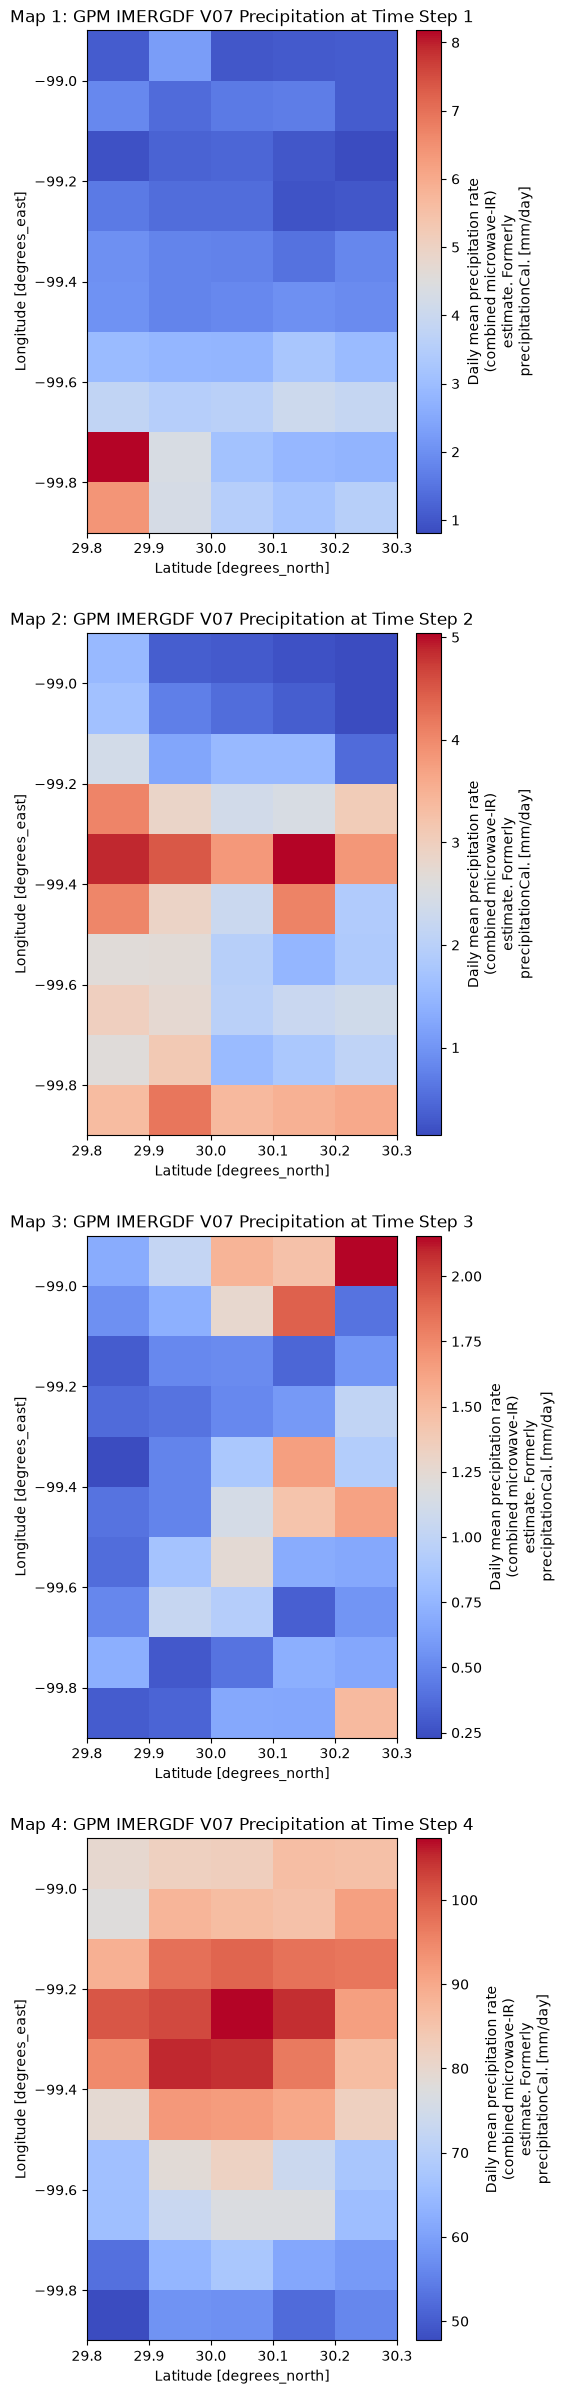

In [2]:
import xarray as xr
import os
import earthaccess
import getpass
import requests
from pydap.net import create_session
import matplotlib.pyplot as plt
%matplotlib inline

# Create search query for 1980-01-01 Cloud OPeNDAP URL
results = earthaccess.search_data(
    short_name="GPM_3IMERGDF",
    version='07',
    temporal=('2025-07-01', '2025-07-04'), # This will stream one granule, but can be edited for a longer temporal extent
    bounding_box=(-99.85886, 29.78140, -98.91769, 30.29064)
)

# Parse out URL from request, add to OPeNDAP URLs list for querying multiple granules with constraint expressions
opendap_urls = []
for item in results:
    for urls in item['umm']['RelatedUrls']:  # Iterate over RelatedUrls in each request step
        if 'OPENDAP' in urls.get('Description', '').upper():  # Check if 'OPENDAP' is in the Description
            # Extract OPeNDAP URL, replace 
            url = urls['URL'].replace('https', 'dap4')

            # Subset T2M, lat, lon, and time
            # To view all variables, comment out these two lines
            ce = "?dap4.ce=/{}%3B/{}%3B/{}%3B/{}".format("precipitation", "lat", "lon", "time")
            url = url + ce

            # Add URL to list
            opendap_urls.append(url)


#authentication using earthaccess
auth = earthaccess.login()
token = earthaccess.get_edl_token()['access_token']
my_session = create_session(session_kwargs={"token": token})

try:
    # Load dataset object and metadata, but don't open the values yet
    # NOTE: When opening HDF files, the group to be accessed must be specified with the "group=" parameter. 
    #       E.g., for GPM IMERG, group="Grid" must be entered or an error will occur
    # Remove the session parameter if you are just using a .netrc file to authenticate
    ds = xr.open_mfdataset(opendap_urls, engine="pydap", session=my_session)
except OSError as e:
    print('Error', e)
    print('Please check that your .edl_token file exists and is valid, or that your username/password were entered correctly.')
    raise

# Define latitude and longitude bounds for CONUS
lat_min, lat_max = 29.78140, 30.29064  # Latitude bounds
lon_min, lon_max = -99.85886, -98.91769  # Longitude bounds

# Subset the dataset based on lat/lon bounds, which is performed server-side
ds_conus = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Plot the first, middle, and last timesteps of the precipitation variables from the subsetted GPM_IMERGDF dataset
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(5, 30))

ds_conus['precipitation'].isel(time=0).plot(ax=ax1, cmap='coolwarm')
ax1.set_title('Map 1: GPM IMERGDF V07 Precipitation at Time Step 1')

ds_conus['precipitation'].isel(time=1).plot(ax=ax2, cmap='coolwarm')
ax2.set_title('Map 2: GPM IMERGDF V07 Precipitation at Time Step 2')

ds_conus['precipitation'].isel(time=2).plot(ax=ax3, cmap='coolwarm')
ax3.set_title('Map 3: GPM IMERGDF V07 Precipitation at Time Step 3')

ds_conus['precipitation'].isel(time=3).plot(ax=ax4, cmap='coolwarm')
ax4.set_title('Map 4: GPM IMERGDF V07 Precipitation at Time Step 4')

plt.show()